In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src


/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from jax.lib import xla_bridge
import jax
print(xla_bridge.get_backend().platform)
name = "cuDNN"
jax._src.lib.cuda_versions.cudnn_get_version()
# jax._src.lib.cuda_versions.cudnn_build_version()
jax.default_device = jax.devices("gpu")[0]

gpu


  0%|          | 0/4500 [00:00<?, ?it/s]

Predict 4500 steps: : 100%|██████████| 4500/4500 [00:00<00:00, 11854.97it/s]


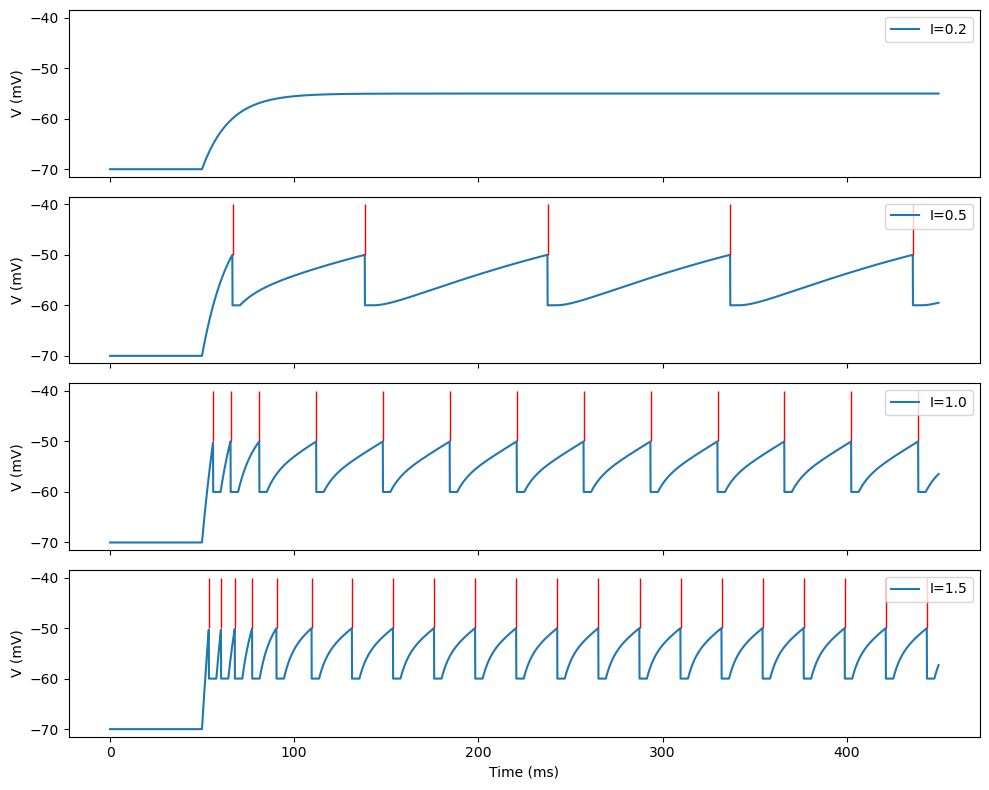

In [40]:
duration = 1000  # Simulation duration in ms
Is = [0.25, 0.5, 1., 1.5]

fig, axes = plt.subplots(len(Is), 1, figsize=(10, 8), sharex=True, sharey=True)

for i, I in enumerate(Is):
    neuron = src.neurons.FNSNeuron(
        size=1,
        C=0.25,
        g_L=0.0167,
        V_L=-70.0,
        V_th=-50.0,
        V_rt=-60.0,
        tau_ref=4.0,
        tau_K=80.0,
        V_initializer=bp.init.Constant(-70.0),
    )

    runner = bp.DSRunner(neuron, monitors=['V', 'input', 'spike'])
    inputs = bp.inputs.section_input([[0.], [I]], [50., 400.], dt=runner.dt)
    runner.run(inputs=inputs)

    axes[i].plot(runner.mon['ts'], runner.mon['V'], label='I=%.1f' % I)
    spikes = np.where(runner.mon['spike'])[0]
    spike_times = runner.mon['ts'][spikes]
    axes[i].vlines(spike_times, neuron.V_th, neuron.V_th+10, color='r', linewidth=1)

    axes[i].set_ylabel('V (mV)')
    axes[i].legend()

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()


In [4]:
from src.models.FNS import FNScircuit
rho = 50
sigma_ee = 0.08
FNSnet = FNScircuit(rho=rho, sigma_ee=sigma_ee)

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warn

In [5]:
FNSnet.to_dict()

{'FNScircuit': {'parameters': {'rho': 50,
   'dx': 1,
   'sigma_ee': 0.08,
   'sigma_ei': 0.1,
   'sigma_ie': 0.1,
   'sigma_ii': 0.125,
   'p_ee': 0.1,
   'p_ei': 0.2,
   'p_ie': 0.3,
   'p_ii': 0.3,
   'boundary': 'periodic',
   'include_self': False,
   'gamma': 4,
   'g': 4,
   'nu': 1,
   'p_ext': 0.1,
   'J_e': 0.01,
   'method': 'exp_auto'},
  'populations': {'E': {'size': (7, 7),
    'C': 0.25,
    'g_L': 0.0167,
    'V_L': -70.0,
    'V_K': -85.0,
    'V_th': -50.0,
    'V_rt': -60.0,
    'tau_ref': 4.0,
    'tau_K': 80.0,
    'Delta_g_K': 0.01,
    'embedding': {'GridPositions': {'domain': (1, 1)}},
    '_V_initializer': {'Uniform': {'min_val': -70.0, 'max_val': -50.0}},
    '_g_K_initializer': 'ZeroInit'},
   'I': {'size': (12,),
    'C': 0.25,
    'g_L': 0.0167,
    'V_L': -70.0,
    'V_K': -85.0,
    'V_th': -50.0,
    'V_rt': -60.0,
    'tau_ref': 4.0,
    'tau_K': 80.0,
    'Delta_g_K': 0.01,
    'embedding': {'RandomPositions': {'domain': (1, 1)}},
    '_V_initializer':

/var/tmp/pbs.13720.headnode/ipykernel_1867361/2893012033.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


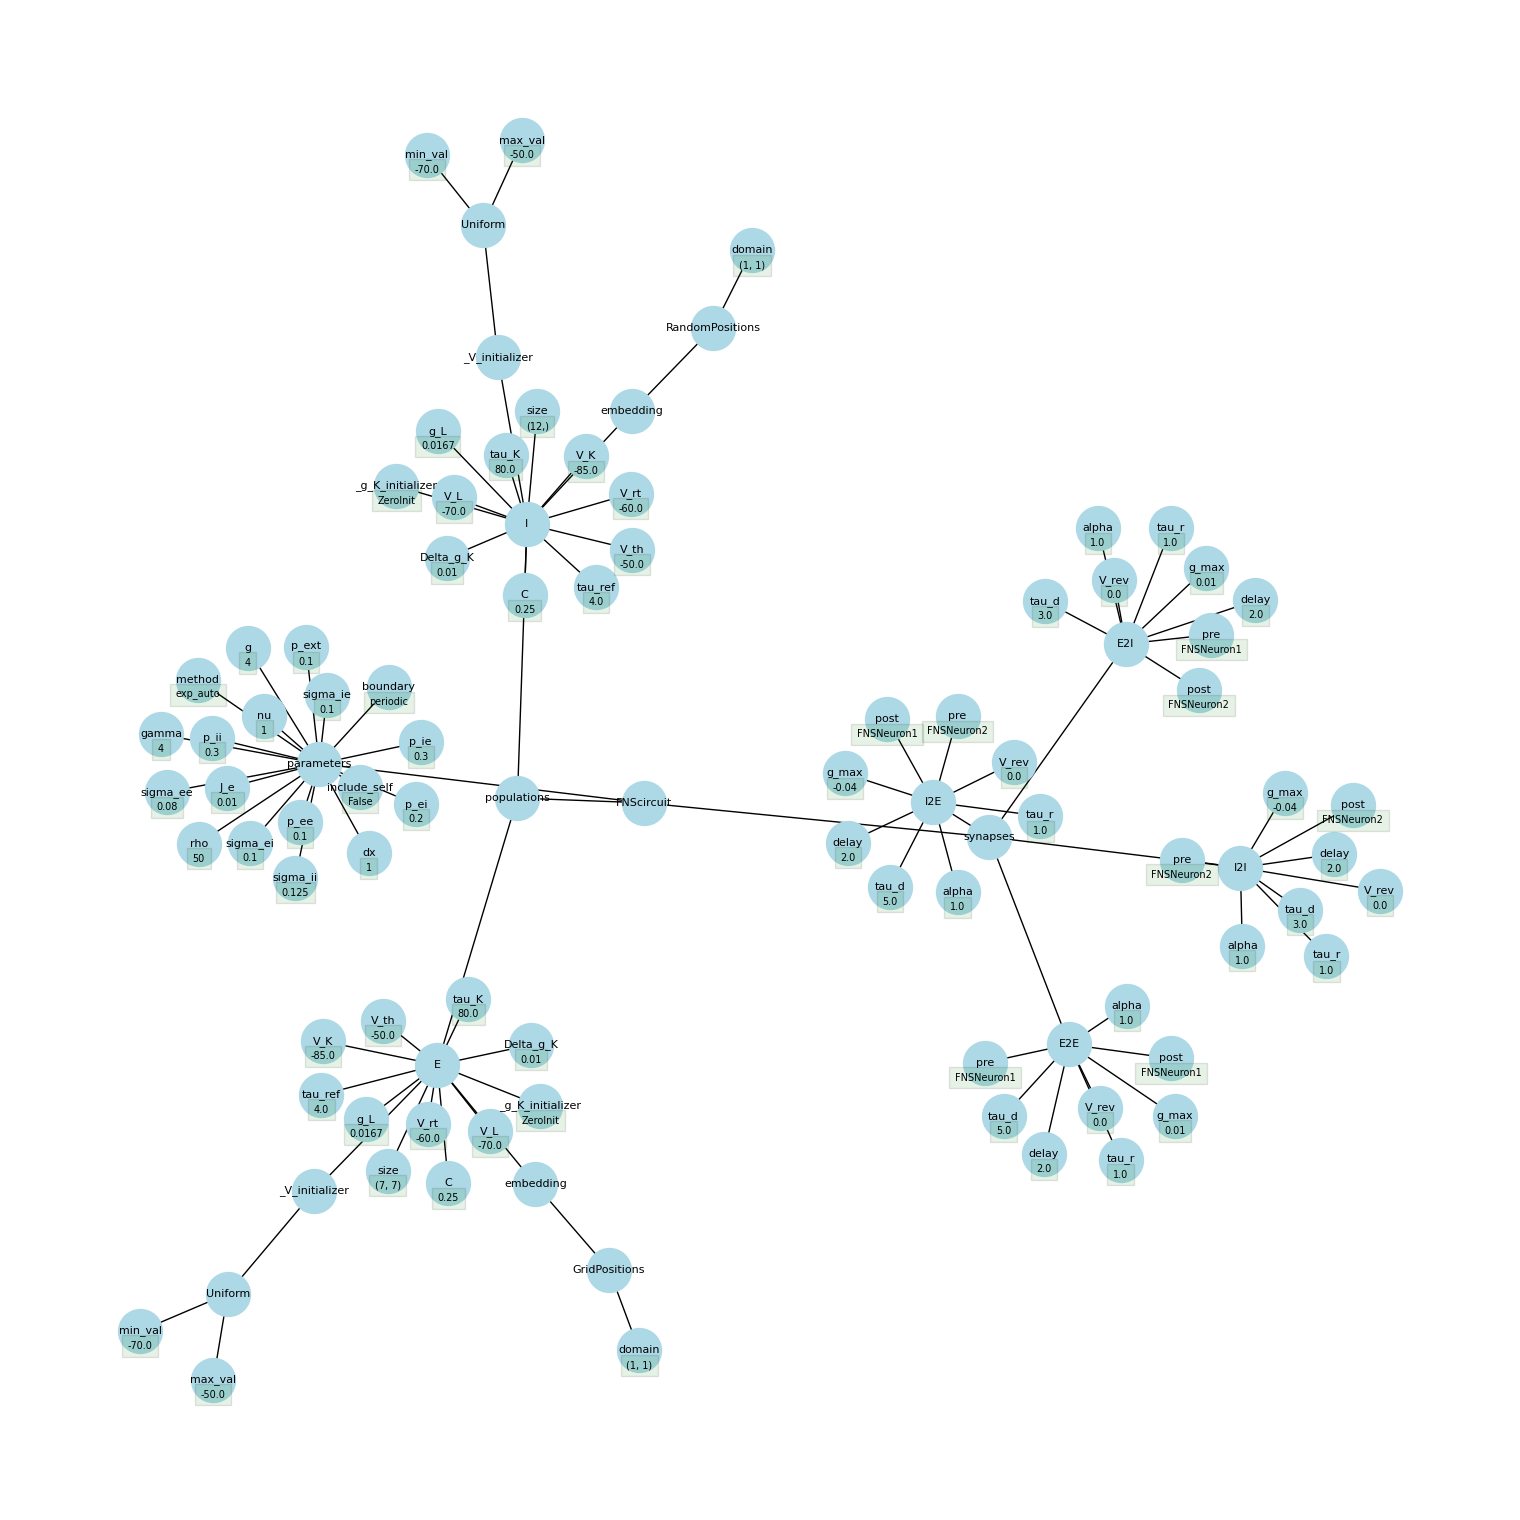

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a directed graph
G = nx.DiGraph()

# Global node counter for unique node IDs
node_counter = 0

def add_nodes_edges(d, G, parent=None):
    """
    Recursively adds nodes and edges to the graph based on the dictionary structure.
    """
    global node_counter
    for key, value in d.items():
        node_id = node_counter
        node_counter += 1
        G.add_node(node_id, label=key)  # Add node with key as label

        if parent is not None:
            G.add_edge(parent, node_id)  # Add edge from parent to current node

        if isinstance(value, dict):
            # If value is a dictionary, recurse
            add_nodes_edges(value, G, parent=node_id)
        else:
            # If value is a leaf node, store the value in node attributes
            G.nodes[node_id]['value'] = value

# Build the graph starting from the root
add_nodes_edges(FNSnet.to_dict(), G)

# Create a mapping of node IDs to labels
labels = {node: G.nodes[node]['label'] for node in G.nodes()}

# Try to use a hierarchical layout; fall back to spring layout if not available
# try:
pos = nx.nx_pydot.graphviz_layout(G, prog="sfdp", root=0)
# except:
# pos = nx.spring_layout(G)

# Draw the nodes and edges
plt.figure(figsize=(15, 15))
nx.draw(G, pos, with_labels=False, arrows=False, node_size=1000, node_color='lightblue')

# Draw node labels (keys)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

# Annotate leaf nodes with their values
for node in G.nodes():
    if 'value' in G.nodes[node]:
        x, y = pos[node]
        value = G.nodes[node]['value']
        # Adjust the position to place the value adjacent to the node
        plt.text(x, y-10, s=str(value), fontsize=7, ha='center', va='center', bbox=dict(facecolor='green', alpha=0.1))

# Display the graph
plt.tight_layout()
plt.show()

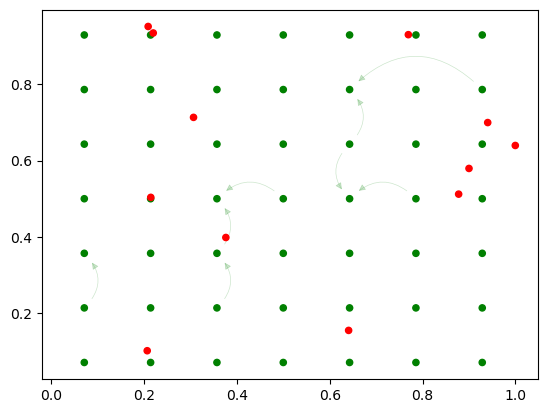

In [7]:
if np.product(FNSnet.E.size) <= 100:
    fig, ax = plt.subplots()
    E2E = FNSnet.E2E.proj.comm.conn.require("conn_mat")
    I2E = FNSnet.I2E.proj.comm.conn.require("conn_mat")
    E2I = FNSnet.E2I.proj.comm.conn.require("conn_mat")
    I2I = FNSnet.I2I.proj.comm.conn.require("conn_mat")
    fullconn = np.block([
        [E2E, E2I],  # Top row: E->E and E->I
        [I2E, I2I]   # Bottom row: I->E and I->I
    ])
    positions = np.concatenate((FNSnet.E.positions, FNSnet.I.positions))

    num_E = len(FNSnet.E.positions)
    num_I = len(FNSnet.I.positions)
    node_colors = ['g'] * num_E + ['r'] * num_I

    G = nx.from_numpy_array(fullconn, create_using=nx.DiGraph())

    nx.draw_networkx_nodes(
        G,
        pos=positions,
        node_color=node_colors,
        node_size=20,
        ax=ax
    )

    # Get the indices of edges
    sources, targets = np.nonzero(fullconn)

    # Determine if source and target nodes are E or I
    node_types = np.array(['g'] * num_E + ['r'] * num_I)
    source_types = node_types[sources]
    target_types = node_types[targets]

    # Set edge colors based on node types
    edge_colors = np.full(len(sources), 'nothing')  # Default color for between-population edges
    edge_colors[(source_types == 'g') & (target_types == 'g')] = 'g'  # E->E edges
    edge_colors[(source_types == 'r') & (target_types == 'r')] = 'r'  # I->I edges
    idxs = (source_types == 'g') & (target_types == 'g') # Only show E->E eges?
    # Draw all edges at once with their respective colors
    nx.draw_networkx_edges(
        G,
        pos=positions,
        edgelist=np.array(list(zip(sources, targets)))[idxs],
        connectionstyle="arc3,rad=0.5",
        edge_color=np.array(edge_colors)[idxs],
        width=0.5,
        alpha=0.2,
        ax=ax
    )
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)



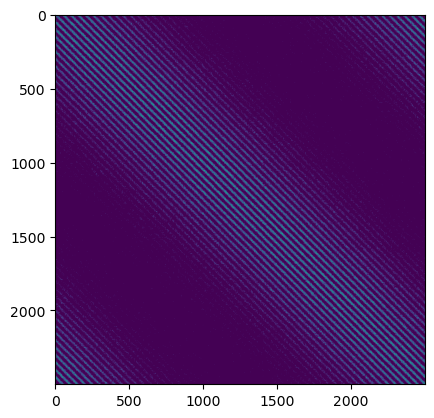

In [8]:
# Optimize construction

conn = src.models.FNS.DistanceDependent(  # This part seems slow... can we fix? or jax?
            src.models.FNS.GaussianKernel(
                sigma=0.125, p_max=0.5,
            ),
            (1, 1),
            src.positions.GridPositions((1, 1))((50, 50)),
            boundary="periodic",
            include_self=False,
        )
plt.imshow(conn.build_mat())

In [9]:
%load_ext line_profiler
%lprun -f src.models.FNS.DistanceDependent.__init__ src.models.FNS.DistanceDependent(    src.models.FNS.GaussianKernel(        sigma=0.125, p_max=0.5,    ),    (1, 1),    src.positions.GridPositions((1, 1))((50, 50)),    boundary="periodic",    include_self=False,)

Timer unit: 1e-09 s

Total time: 1.14639 s
File: /headnode2/bhar9988/code/DDC/Dewdrop.jl/src/models/FNS.py
Function: __init__ at line 82

Line #      Hits         Time  Per Hit   % Time  Line Contents
    82                                               def __init__(
    83                                                   self,
    84                                                   kernel,
    85                                                   domain,
    86                                                   positions_pre,
    87                                                   positions_post=None,
    88                                                   boundary="periodic",
    89                                                   distance_metric=euclidean_distance,
    90                                                   include_self=True,
    91                                                   seed=None,
    92                                                   **kwargs,
    93 

/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/jax/_src/ops/scatter.py:96: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warn

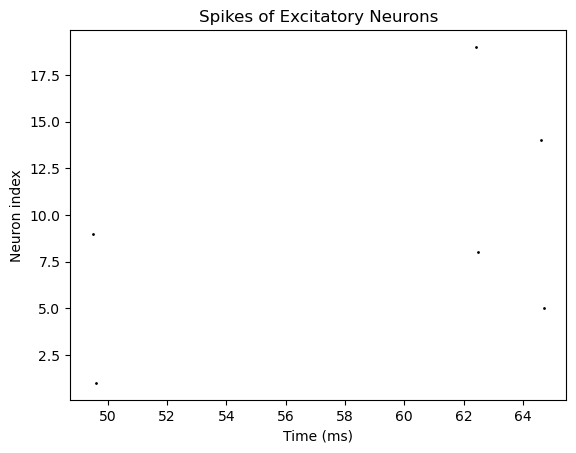

In [10]:
# Simulate
FNSnet = FNScircuit(rho=30, nu=1.)
runner = bp.DSRunner(FNSnet, monitors=['E.spike'], )
runner.run(duration=100.)

t = runner.mon['ts'].view()
X = runner.mon['E.spike'].view()
bp.visualize.raster_plot(t, X, title='Spikes of Excitatory Neurons', show=True)